# Praktikum Week 10: Variasi K-Means

Notebook ini memakai library siap pakai, bukan implementasi from scratch:

- `kmodes` untuk K-Modes dan K-Prototypes
- `kmedoids` untuk K-Medoids
- `scikit-learn` untuk K-Means dan Spectral Clustering

Tujuannya adalah memahami kapan masing-masing metode dipakai dan bagaimana membaca output-nya.

## 1. Import Library

In [1]:
from pathlib import Path

import kmedoids
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.datasets import load_breast_cancer, load_iris, make_circles
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler

OUTPUT_DIR = Path('../figures')
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## 2. K-Modes untuk Data Kategorikal

K-Modes dipakai ketika fitur yang dianalisis berupa kategori. Di contoh ini, dataset Breast Cancer yang awalnya numerik didiskritisasi menjadi kategori `Low`, `Medium`, dan `High`.

In [2]:
cancer = load_breast_cancer(as_frame=True)
numeric = cancer.data

selected_cols = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean smoothness',
    'worst radius',
    'worst texture',
    'worst perimeter',
]
selected = numeric[selected_cols]

discretizer = KBinsDiscretizer(
    n_bins=3,
    encode='ordinal',
    strategy='quantile',
    quantile_method='averaged_inverted_cdf',
)
discretized = discretizer.fit_transform(selected).astype(int)
category_labels = np.array(['Low', 'Medium', 'High'])
categorical = pd.DataFrame(category_labels[discretized], columns=selected_cols)

kmodes_model = KModes(n_clusters=2, init='Huang', n_init=5, random_state=RANDOM_STATE)
kmodes_labels = kmodes_model.fit_predict(categorical)

result_kmodes = categorical.copy()
result_kmodes['cluster'] = kmodes_labels
result_kmodes['diagnosis'] = cancer.target_names[cancer.target]

display(result_kmodes.head())
display(pd.DataFrame(kmodes_model.cluster_centroids_, columns=selected_cols))
display(pd.crosstab(result_kmodes['cluster'], result_kmodes['diagnosis']))
print(f'K-Modes cost: {kmodes_model.cost_:.2f}')

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,worst radius,worst texture,worst perimeter,cluster,diagnosis
0,High,Low,High,High,High,High,Low,High,0,malignant
1,High,Medium,High,High,Low,High,Medium,High,0,malignant
2,High,High,High,High,High,High,Medium,High,0,malignant
3,Low,Medium,Low,Low,High,Medium,Medium,Medium,1,malignant
4,High,Low,High,High,Medium,High,Low,High,0,malignant


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,worst radius,worst texture,worst perimeter
0,High,High,High,High,High,High,High,High
1,Low,Low,Low,Low,Low,Low,Low,Low


diagnosis,benign,malignant
cluster,,
0,78,204
1,279,8


K-Modes cost: 1811.00


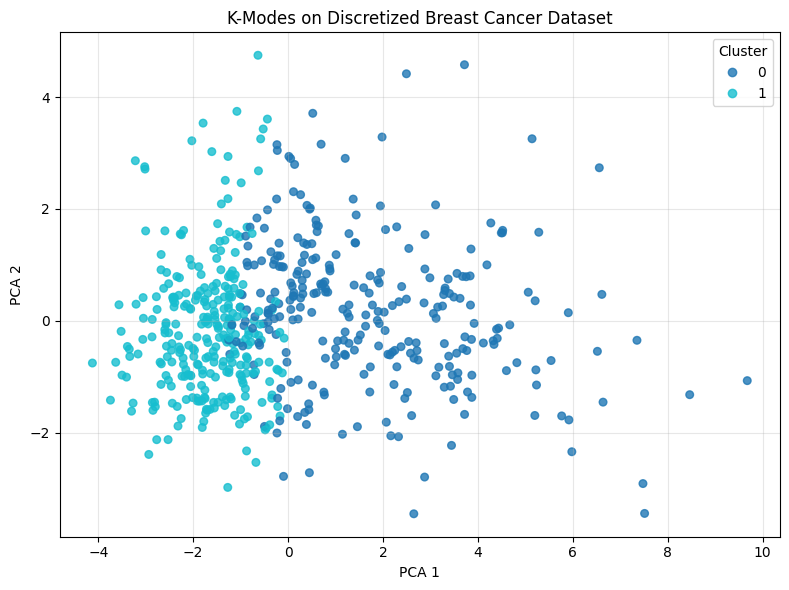

In [3]:
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(
    StandardScaler().fit_transform(selected)
)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=kmodes_labels, cmap='tab10', s=30, alpha=0.8)
ax.set_title('K-Modes on Discretized Breast Cancer Dataset')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.legend(*scatter.legend_elements(), title='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_kmodes_breast_cancer_pca.png', dpi=150)
plt.show()

## 3. K-Prototypes untuk Data Campuran

K-Prototypes dipakai ketika dataset punya fitur numerik dan kategorikal sekaligus. Contoh ini memakai Palmer Penguins.

In [4]:
penguins_url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
penguins = pd.read_csv(penguins_url)
needed_cols = [
    'species',
    'island',
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g',
    'sex',
]
penguins = penguins[needed_cols].dropna().reset_index(drop=True)

numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_cols = ['island', 'sex']

scaled_numeric = StandardScaler().fit_transform(penguins[numeric_cols])
mixed = pd.DataFrame(scaled_numeric, columns=numeric_cols)
for col in categorical_cols:
    mixed[col] = penguins[col].astype(str)

X_mixed = mixed.to_numpy(dtype=object)
categorical_idx = [mixed.columns.get_loc(col) for col in categorical_cols]

kproto_model = KPrototypes(n_clusters=3, init='Huang', n_init=5, gamma=1.0, random_state=RANDOM_STATE)
kproto_labels = kproto_model.fit_predict(X_mixed, categorical=categorical_idx)

result_kproto = penguins.copy()
result_kproto['cluster'] = kproto_labels

display(result_kproto.head())
display(pd.crosstab(result_kproto['cluster'], result_kproto['species']))
print(f'K-Prototypes cost: {kproto_model.cost_:.2f}')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,2


species,Adelie,Chinstrap,Gentoo
cluster,,,
0,90,16,0
1,0,0,119
2,56,52,0


K-Prototypes cost: 584.20


,cluster,size,mean_bill_length_mm,mean_bill_depth_mm,mean_flipper_length_mm,mean_body_mass_g,mode_island,mode_sex
0,0,106,38.62,17.68,187.68,3427.83,Dream,FEMALE
1,1,119,47.57,15.00,217.24,5092.44,Biscoe,MALE
2,2,108,45.33,19.05,196.08,3996.30,Dream,MALE


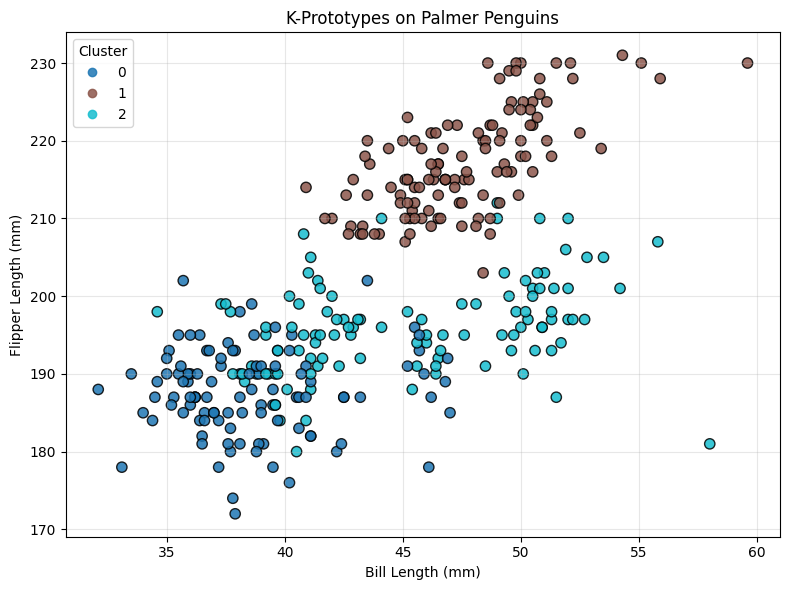

In [5]:
profile_rows = []
for cluster_id in sorted(result_kproto['cluster'].unique()):
    subset = result_kproto[result_kproto['cluster'] == cluster_id]
    row = {'cluster': cluster_id, 'size': len(subset)}
    for col in numeric_cols:
        row[f'mean_{col}'] = round(float(subset[col].mean()), 2)
    for col in categorical_cols:
        row[f'mode_{col}'] = subset[col].mode(dropna=True).iloc[0]
    profile_rows.append(row)

display(pd.DataFrame(profile_rows))

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    result_kproto['bill_length_mm'],
    result_kproto['flipper_length_mm'],
    c=kproto_labels,
    cmap='tab10',
    s=55,
    alpha=0.85,
    edgecolors='black',
)
ax.set_title('K-Prototypes on Palmer Penguins')
ax.set_xlabel('Bill Length (mm)')
ax.set_ylabel('Flipper Length (mm)')
ax.legend(*scatter.legend_elements(), title='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_kprototypes_penguins.png', dpi=150)
plt.show()

## 4. K-Medoids untuk Data Numerik dengan Medoid

K-Medoids memakai data asli sebagai pusat cluster. Notebook ini memakai library `kmedoids`, bukan implementasi manual.

In [6]:
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

kmeans_iris = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_kmeans_iris = kmeans_iris.fit_predict(X_iris)

distance_iris = pairwise_distances(X_iris, metric='euclidean')
kmedoids_result = kmedoids.fasterpam(distance_iris, 3)
labels_kmedoids_iris = np.asarray(kmedoids_result.labels)
medoid_indices = np.asarray(kmedoids_result.medoids)
medoid_centers = X_iris[medoid_indices]

print(f'ARI K-Means  : {adjusted_rand_score(y_iris, labels_kmeans_iris):.3f}')
print(f'ARI K-Medoids: {adjusted_rand_score(y_iris, labels_kmedoids_iris):.3f}')
print('Medoid indices:', medoid_indices)
print(f'K-Medoids loss: {kmedoids_result.loss:.2f}')

ARI K-Means  : 0.620
ARI K-Medoids: 0.676
Medoid indices: [ 94   7 147]
K-Medoids loss: 130.73


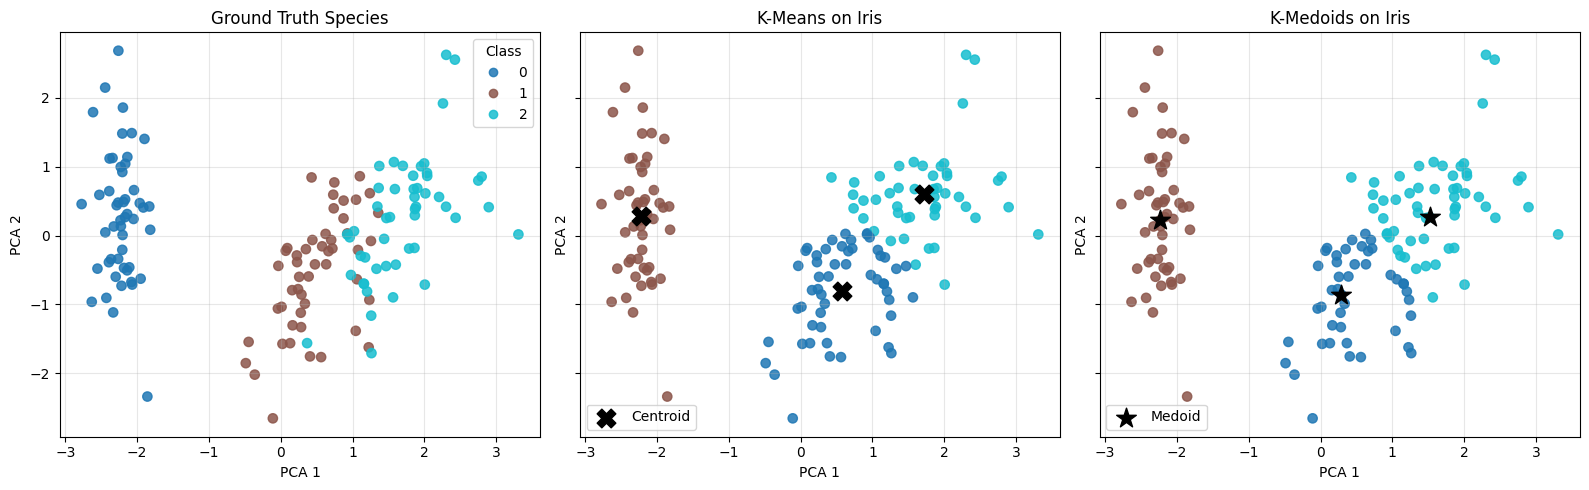

In [7]:
pca_iris = PCA(n_components=2, random_state=RANDOM_STATE)
coords_iris = pca_iris.fit_transform(X_iris)
kmeans_centers_2d = pca_iris.transform(kmeans_iris.cluster_centers_)
medoid_centers_2d = pca_iris.transform(medoid_centers)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
plots = [
    (y_iris, 'Ground Truth Species'),
    (labels_kmeans_iris, 'K-Means on Iris'),
    (labels_kmedoids_iris, 'K-Medoids on Iris'),
]

for ax, (labels, title) in zip(axes, plots):
    scatter = ax.scatter(coords_iris[:, 0], coords_iris[:, 1], c=labels, cmap='tab10', s=45, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.grid(True, alpha=0.3)

axes[1].scatter(kmeans_centers_2d[:, 0], kmeans_centers_2d[:, 1], marker='X', c='black', s=180, label='Centroid')
axes[1].legend()
axes[2].scatter(medoid_centers_2d[:, 0], medoid_centers_2d[:, 1], marker='*', c='black', s=220, label='Medoid')
axes[2].legend()
axes[0].legend(*scatter.legend_elements(), title='Class')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_kmedoids_iris_comparison.png', dpi=150)
plt.show()

## 5. Spectral Clustering untuk Pola Non-Linear

Untuk demo praktis kernel/similarity-based clustering, gunakan `SpectralClustering`. Contoh berikut memakai noisy circles.

In [8]:
X_circles, y_circles = make_circles(n_samples=450, factor=0.45, noise=0.06, random_state=RANDOM_STATE)
X_circles_scaled = StandardScaler().fit_transform(X_circles)
gamma = 8.0

labels_kmeans_circles = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_circles_scaled)
labels_spectral_circles = SpectralClustering(
    n_clusters=2,
    affinity='rbf',
    gamma=gamma,
    random_state=RANDOM_STATE,
).fit_predict(X_circles_scaled)

print(f'ARI K-Means     : {adjusted_rand_score(y_circles, labels_kmeans_circles):.3f}')
print(f'ARI Spectral RBF: {adjusted_rand_score(y_circles, labels_spectral_circles):.3f}')

ARI K-Means     : -0.002
ARI Spectral RBF: 1.000


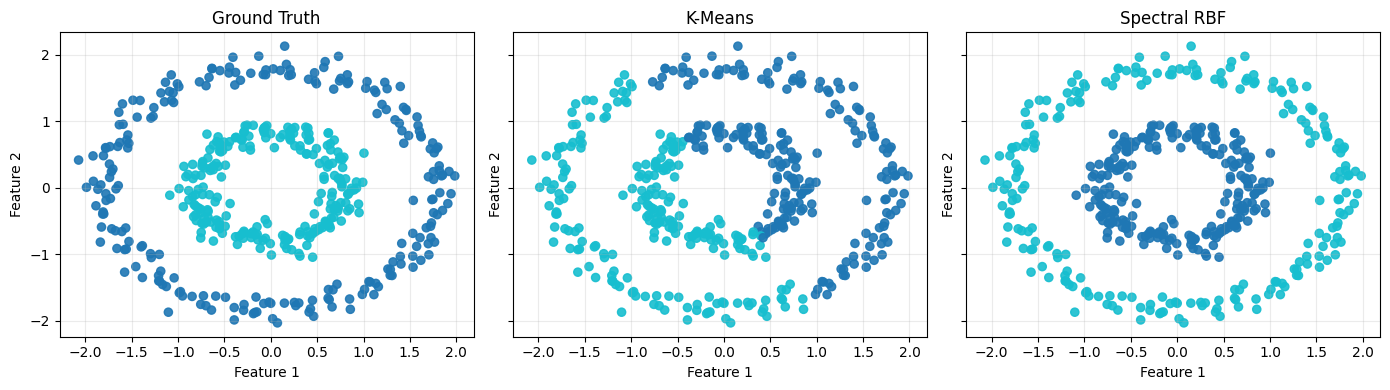

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
plots = [
    (y_circles, 'Ground Truth'),
    (labels_kmeans_circles, 'K-Means'),
    (labels_spectral_circles, 'Spectral RBF'),
]

for ax, (labels, title) in zip(axes, plots):
    ax.scatter(X_circles_scaled[:, 0], X_circles_scaled[:, 1], c=labels, cmap='tab10', s=35, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_kernel_kmeans_circles.png', dpi=150)
plt.show()

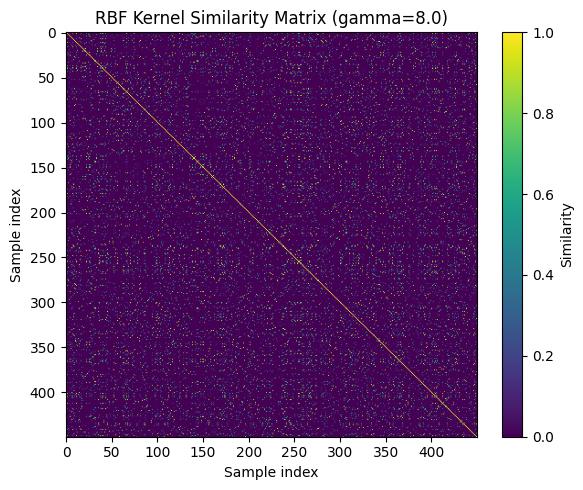

In [10]:
kernel = rbf_kernel(X_circles_scaled, gamma=gamma)
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(kernel, cmap='viridis', aspect='auto')
ax.set_title(f'RBF Kernel Similarity Matrix (gamma={gamma})')
ax.set_xlabel('Sample index')
ax.set_ylabel('Sample index')
plt.colorbar(image, ax=ax, label='Similarity')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_rbf_kernel_similarity_matrix.png', dpi=150)
plt.show()